# Exploratory Data Analysis (EDA)
## Sentiment Analysis Review Mobile Legends

## 1. Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [2]:
df = pd.read_csv('../data/mobile_legends_reviews_cleaned1.csv')
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,a88d9682-8a77-433a-825c-493070197e3d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aku turunkan rating bintang nya. Tolong pelaku...,1,5129,1.9.48.10373,2025-03-08 02:16:20,NaN,NaN,1.9.48.10373
1,97add647-794f-42eb-a02e-fd58f5a424a5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Game nya diperbarui lagi lah! Enak enak main r...,1,1090,1.9.48.10373,2025-03-03 09:17:47,NaN,NaN,1.9.48.10373
2,c1482b0d-47a9-422f-a30c-df75e8624192,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Kondisi lag saat di tengah game sering banget ...,1,293,1.9.48.10373,2025-03-10 14:35:22,NaN,NaN,1.9.48.10373
3,a6efbddf-25c1-4de5-bf04-7fe3109e0b96,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Montonnnnn, gimana sih. Gak sekali dua kali pa...",3,652,1.9.48.10373,2025-03-04 10:49:14,NaN,NaN,1.9.48.10373
4,7f35b682-b6f4-40ec-a3bd-41b9e8e5f3f8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sama saja kasih skin tapi dibuat kalah terus. ...,1,1699,1.9.48.10373,2025-02-26 14:09:53,NaN,NaN,1.9.48.10373


## 3. Melihat Ukuran Dataset

In [3]:
print(df.shape)
print(df.columns)

(10000, 11)
Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion'],
      dtype='str')


## 4. Informasi Dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   reviewId              10000 non-null  str  
 1   userName              10000 non-null  str  
 2   userImage             10000 non-null  str  
 3   content               10000 non-null  str  
 4   score                 10000 non-null  int64
 5   thumbsUpCount         10000 non-null  int64
 6   reviewCreatedVersion  9997 non-null   str  
 7   at                    10000 non-null  str  
 8   replyContent          421 non-null    str  
 9   repliedAt             421 non-null    str  
 10  appVersion            9997 non-null   str  
dtypes: int64(2), str(9)
memory usage: 859.5 KB


## 5. Cek Missing Value

In [5]:
df.isnull().sum()

reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion       3
at                         0
replyContent            9579
repliedAt               9579
appVersion                 3
dtype: int64

## 6. Cek Duplikat

In [6]:
print('Jumlah data duplikat:', df.duplicated().sum())

Jumlah data duplikat: 0


## 7. Membuat Label Sentimen

In [9]:
def convert_sentiment(score):
    if score <= 2:
        return 'negatif'
    elif score == 3:
        return 'netral'
    else:
        return 'positif'


df['sentiment'] = df['score'].apply(convert_sentiment)

print(df[['score', 'sentiment']].head())
print(df['sentiment'].value_counts())

   score sentiment
0      1   negatif
1      1   negatif
2      1   negatif
3      3    netral
4      1   negatif
sentiment
negatif    6747
positif    2373
netral      880
Name: count, dtype: int64


## 8. Distribusi Sentimen

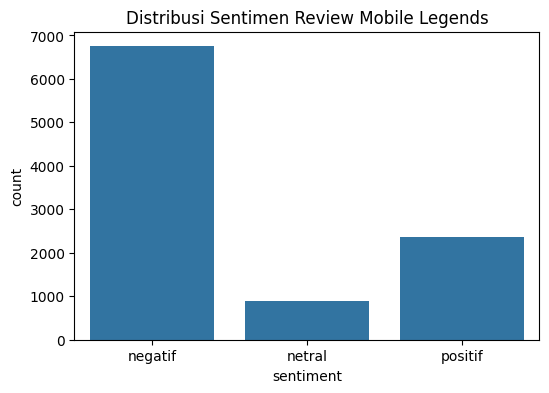

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sentiment')
plt.title('Distribusi Sentimen Review Mobile Legends')
plt.show()

## 9. Contoh Review Tiap Sentimen

In [13]:
print('Positif:')
print(df[df['sentiment']=='positif']['content'].iloc[0])

print('\nNegatif:')
print(df[df['sentiment']=='negatif']['content'].iloc[0])

print('\nNetral:')
print(df[df['sentiment']=='netral']['content'].iloc[0])


Positif:
Semakin kesini mlbb makin banyak lag, padahal untuk penyimpanan masih banyak ruang, apalagi saat war sering ngelag nanti kalo udah mati baru jalan lagi. Saat aku cek peforma jaringan udah sangat stabil.

Negatif:
Aku turunkan rating bintang nya. Tolong pelaku cheat dan RW di blacklist. Sering mengalami pas masuk in game tiba² ping naik dan tidak bisa lanjut main, bahakan tidak bisa masuk in game nya. Padahal jaringan Aman² saja. Tolong diperketat lagi untuk keamanannya demi kenyamanan bermain.

Netral:
Montonnnnn, gimana sih. Gak sekali dua kali pas di tengah-tengah Mach lag, dan lag nya bukan karena sinyal, padahal sinyal bagus. Dan yang ngalamin nya juga bukan saya juga tapi tim saya sama musuh juga. Terus mana lama bagetttt. Gonta-ganti ke wifi-data atau sebaliknya juga gak bener, masih saja lag, sinyal merah padahal kalo buka apk lain lancar. Ihhh nyebelin mana lagi rank😒


## 10. Panjang Teks Review

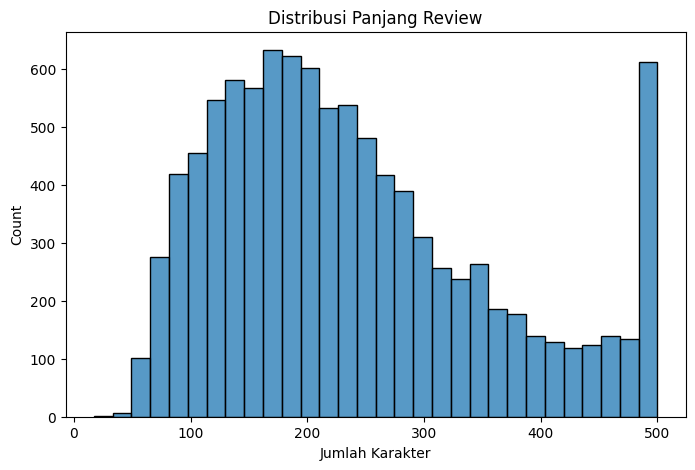

In [14]:
df['text_length'] = df['content'].astype(str).apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=30)
plt.title('Distribusi Panjang Review')
plt.xlabel('Jumlah Karakter')
plt.show()

## 11. Rata-rata Panjang Review per Sentimen

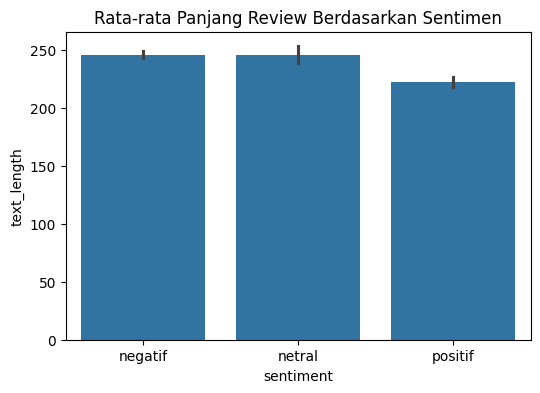

In [15]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='sentiment', y='text_length')
plt.title('Rata-rata Panjang Review Berdasarkan Sentimen')
plt.show()